# Fine-tuning le model SI2M-Lab/DarijaBERT

Dans ce notebook, nous allons entraîner un modèle de classification de texte en utilisant un dataset spécifique. Nous allons utiliser la bibliothèque `transformers` de Hugging Face pour charger un modèle BERT préexistant, appliquer la configuration LoRA (Low-Rank Adaptation), et entraîner le modèle avec un ensemble de données annotées.

## Étapes:
1. Charger et prétraiter les données.
2. Configurer et charger le modèle de pré-entrainement.
3. Appliquer LoRA au modèle.
4. Configurer et entraîner le modèle.
5. Sauvegarder le modèle final.

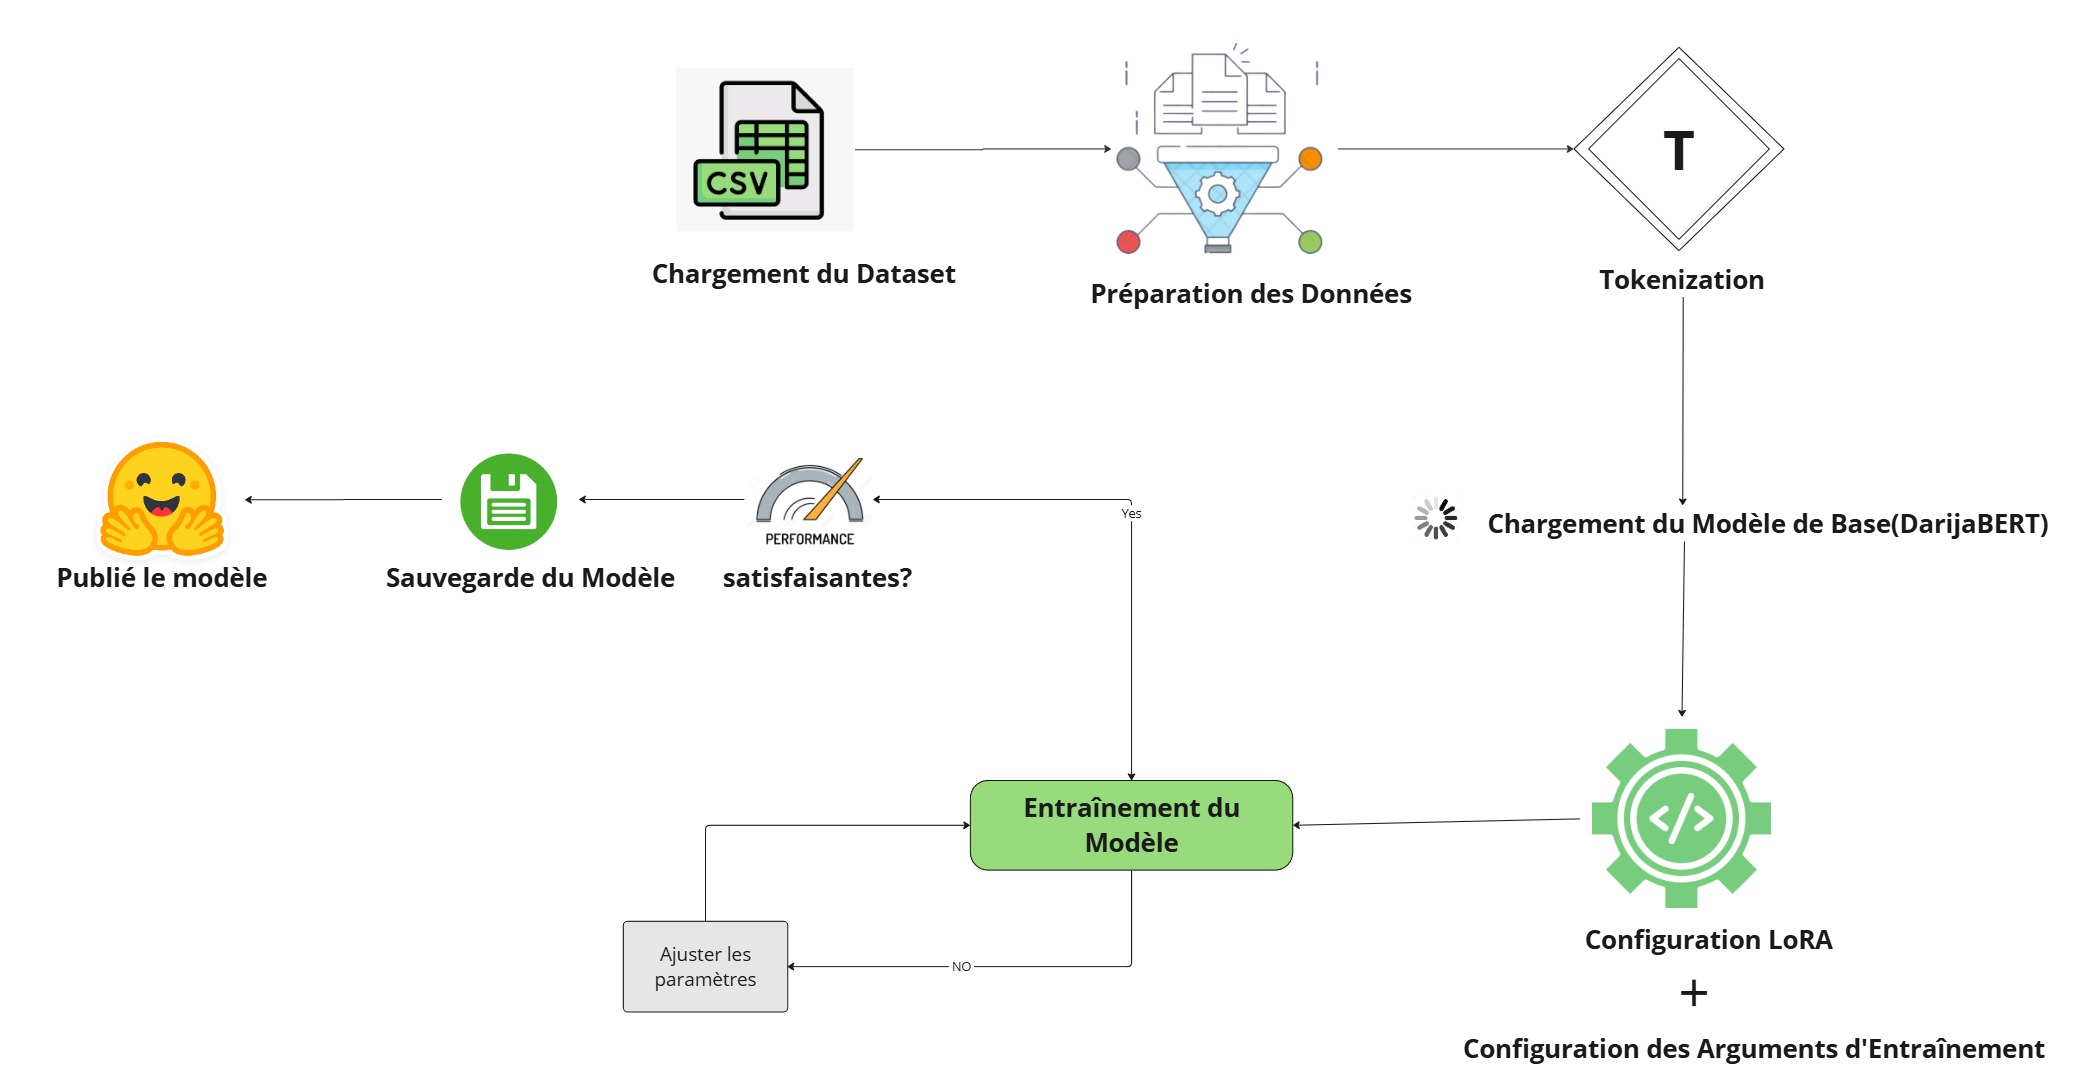

In [3]:
# Importation des bibliothèques nécessaires
from transformers import Trainer, TrainingArguments, AutoTokenizer, AutoModelForSequenceClassification
from transformers import EvalPrediction
from peft import get_peft_model, LoraConfig, TaskType
from datasets import Dataset
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

## 1. Chargement et Prétraitement des Données

Nous commençons par charger le dataset et vérifier qu'il contient les colonnes nécessaires pour l'entraînement. Ensuite, nous encoderons les étiquettes textuelles en entiers et diviserons les données en ensembles d'entraînement et de validation.


In [4]:
# Charger le dataset
df = pd.read_csv('dataset_darija2.csv')

# Vérification des colonnes nécessaires
if 'Text' not in df.columns or 'Label' not in df.columns:
    raise ValueError("Le dataset doit contenir les colonnes 'Text' et 'Label'.")

# Convertir les labels en entiers
label_encoder = LabelEncoder()
df['Label'] = label_encoder.fit_transform(df['Label'])

# Diviser le dataset en ensembles d'entraînement et de validation
train_df, val_df = train_test_split(df, test_size=0.2, stratify=df['Label'], random_state=42)

# Convertir les DataFrames en objets Dataset de Hugging Face
train_dataset = Dataset.from_pandas(train_df)
val_dataset = Dataset.from_pandas(val_df)


## 2. Chargement et Tokenization des Données

Ensuite, nous allons charger un tokenizer pré-entraîné pour le modèle et l'appliquer sur nos données. Le tokenizer convertira le texte en tokens numériques afin qu'il puisse être traité par le modèle.

In [5]:
# Charger le tokenizer
tokenizer = AutoTokenizer.from_pretrained("SI2M-Lab/DarijaBERT")

# Tokenizer les données avec padding
def tokenize_function(examples):
    return tokenizer(
        examples['Text'],
        padding="max_length",
        truncation=True,
        max_length=128
    )

# Appliquer le tokenizer aux ensembles d'entraînement et de validation
train_dataset = train_dataset.map(tokenize_function, batched=True)
val_dataset = val_dataset.map(tokenize_function, batched=True)

# Ajouter les labels au dataset
train_dataset = train_dataset.map(lambda x: {'labels': x['Label']})
val_dataset = val_dataset.map(lambda x: {'labels': x['Label']})


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/307 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/779 [00:00<?, ?B/s]

The `xla_device` argument has been deprecated in v4.4.0 of Transformers. It is ignored and you can safely remove it from your `config.json` file.


vocab.txt:   0%|          | 0.00/879k [00:00<?, ?B/s]

...

The `xla_device` argument has been deprecated in v4.4.0 of Transformers. It is ignored and you can safely remove it from your `config.json` file.


Map:   0%|          | 0/1454 [00:00<?, ? examples/s]

Map:   0%|          | 0/364 [00:00<?, ? examples/s]

Map:   0%|          | 0/1454 [00:00<?, ? examples/s]

Map:   0%|          | 0/364 [00:00<?, ? examples/s]

## 3. Configuration du Modèle avec LoRA

Nous allons maintenant charger un modèle pré-entraîné pour la classification de séquences. Ensuite, nous appliquerons la configuration LoRA afin d'ajouter un mécanisme d'adaptation bas-rang aux couches du modèle pour améliorer l'efficacité de l'entraînement.


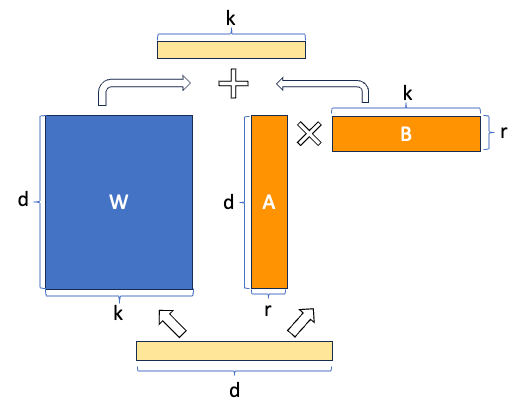

In [6]:
# Charger le modèle pour la classification de séquences
model = AutoModelForSequenceClassification.from_pretrained(
    "SI2M-Lab/DarijaBERT",
    num_labels=len(label_encoder.classes_)
)

# Configuration LoRA
lora_config = LoraConfig(
    task_type=TaskType.SEQ_CLS,        # Spécifie la tâche de classification de séquences
    r=8,                               # Rang de la décomposition (plus petit = moins de paramètres)
    lora_alpha=32,                     # Facteur de mise à l'échelle des matrices d'adaptation
    lora_dropout=0.1,                  # Taux de dropout appliqué pendant l’entraînement sur les matrices LoRA
    target_modules=["query", "value"], # Modules ciblés pour l'adaptation (ici les matrices d'attention "query" et "value")
)
model = get_peft_model(model, lora_config)


The `xla_device` argument has been deprecated in v4.4.0 of Transformers. It is ignored and you can safely remove it from your `config.json` file.


model.safetensors:   0%|          | 0.00/836M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at SI2M-Lab/DarijaBERT and are newly initialized: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight', 'classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


## 4. Définition des Métriques et des Arguments d'Entraînement

Nous définirons ensuite une fonction pour évaluer les performances du modèle pendant l'entraînement en utilisant les métriques de précision, rappel et F1. Ensuite, nous configurons les arguments d'entraînement.


In [7]:
# Définir les métriques d'évaluation
def compute_metrics(p: EvalPrediction):
    preds = p.predictions.argmax(-1)
    precision, recall, f1, _ = precision_recall_fscore_support(p.label_ids, preds, average='weighted')
    acc = accuracy_score(p.label_ids, preds)
    return {"accuracy": acc, "f1": f1, "precision": precision, "recall": recall}

# Définir les arguments d'entraînement
training_args = TrainingArguments(
    output_dir="./results",
    evaluation_strategy="epoch",
    save_strategy="epoch",
    learning_rate=3e-5,  # Augmenter légèrement le learning rate
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=10,  # Augmenter le nombre d'époques
    weight_decay=0.01,
    logging_dir='./logs',
    logging_steps=10,
    save_total_limit=2,
    load_best_model_at_end=True,  # Charger le meilleur modèle à la fin
    metric_for_best_model="f1",
)


/usr/local/lib/python3.11/dist-packages/transformers/training_args.py:1575: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(


## 5. Entraînement et Sauvegarde du Modèle

Nous initialisons le `Trainer` avec les arguments définis et commençons l'entraînement. Une fois l'entraînement terminé, nous sauvegardons le modèle et le tokenizer.


In [9]:
# Définir le Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
    tokenizer=tokenizer,
)

# Entraîner le modèle
trainer.train()


<ipython-input-9-92228b1d6bc6>:2: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


<IPython.core.display.Javascript object>

wandb: Logging into wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: You can find your API key in your browser here: https://wandb.ai/authorize
wandb: Paste an API key from your profile and hit enter, or press ctrl+c to quit:

 ··········


wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Using wandb-core as the SDK backend.  Please refer to https://wandb.me/wandb-core for more information.


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,2.251900,2.196183,0.217033,0.155718,0.219417,0.217033
2,2.103400,2.037756,0.370879,0.323178,0.410647,0.370879
3,1.930400,1.832816,0.458791,0.404074,0.530674,0.458791
4,1.747600,1.643897,0.565934,0.541918,0.631223,0.565934
5,1.502600,1.493751,0.681319,0.669868,0.688434,0.681319
6,1.469800,1.369634,0.747253,0.737764,0.744846,0.747253
7,1.347500,1.275150,0.774725,0.765022,0.774305,0.774725
8,1.340500,1.214261,0.785714,0.777039,0.792802,0.785714
9,1.209600,1.178994,0.788462,0.780683,0.796470,0.788462
10,1.242200,1.167954,0.796703,0.789193,0.802839,0.796703


The `xla_device` argument has been deprecated in v4.4.0 of Transformers. It is ignored and you can safely remove it from your `config.json` file.
The `xla_device` argument has been deprecated in v4.4.0 of Transformers. It is ignored and you can safely remove it from your `config.json` file.
The `xla_device` argument has been deprecated in v4.4.0 of Transformers. It is ignored and you can safely remove it from your `config.json` file.
The `xla_device` argument has been deprecated in v4.4.0 of Transformers. It is ignored and you can safely remove it from your `config.json` file.
The `xla_device` argument has been deprecated in v4.4.0 of Transformers. It is ignored and you can safely remove it from your `config.json` file.
The `xla_device` argument has been deprecated in v4.4.0 of Transformers. It is ignored and you can safely remove it from your `config.json` file.
The `xla_device` argument has been deprecated in v4.4.0 of Transformers. It is ignored and you can safely remove it from you

TrainOutput(global_step=910, training_loss=1.6659850707420936, metrics={'train_runtime': 349.5752, 'train_samples_per_second': 41.593, 'train_steps_per_second': 2.603, 'total_flos': 959856455700480.0, 'train_loss': 1.6659850707420936, 'epoch': 10.0})

In [20]:
from transformers import BertForSequenceClassification, BertTokenizer

# Charger le modèle et le tokenizer depuis votre répertoire LoRA existant
model = BertForSequenceClassification.from_pretrained("./LORA_model", num_labels=10)
tokenizer = BertTokenizer.from_pretrained("./LORA_model")

# Sauvegarder le modèle avec la nouvelle configuration
model.save_pretrained("./LORA_model_adjusted")
tokenizer.save_pretrained("./LORA_model_adjusted")

print("Modèle et tokenizer sauvegardés avec succès dans './LORA_model_adjusted'")


The `xla_device` argument has been deprecated in v4.4.0 of Transformers. It is ignored and you can safely remove it from your `config.json` file.
Some weights of BertForSequenceClassification were not initialized from the model checkpoint at SI2M-Lab/DarijaBERT and are newly initialized: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight', 'classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
The `xla_device` argument has been deprecated in v4.4.0 of Transformers. It is ignored and you can safely remove it from your `config.json` file.


Modèle et tokenizer sauvegardés avec succès dans './LORA_model_adjusted'


## 6. Affichage de la Matrice de Confusion

Après l'entraînement du modèle, il est utile de visualiser la performance du modèle en affichant une matrice de confusion. Cela permet de mieux comprendre comment le modèle fait ses prédictions pour chaque classe.


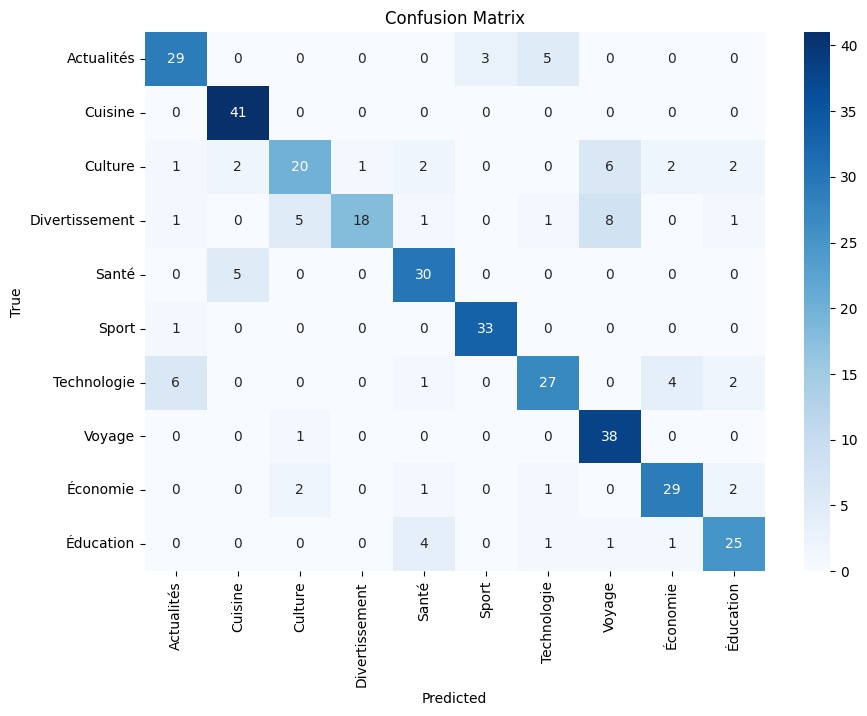

In [21]:
# Importer les bibliothèques nécessaires pour la matrice de confusion
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Prédictions sur l'ensemble de validation
pred_labels = trainer.predict(val_dataset).predictions.argmax(axis=-1)
val_labels = val_dataset["labels"]

# Matrice de confusion
conf_matrix = confusion_matrix(val_labels, pred_labels)

# Affichage de la matrice de confusion
plt.figure(figsize=(10, 7))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()


In [12]:
pip install huggingface_hub

In [22]:
from huggingface_hub import login

login()

In [25]:
# Définir un nom pour votre dépôt sur Hugging Face
repo_name = "DarijaBERT-finetuned_model_with_LORA"

# Publier sur Hugging Face Hub
model.push_to_hub(repo_name)
tokenizer.push_to_hub(repo_name)

print(f"Modèle publié sur Hugging Face : https://huggingface.co/{repo_name}")

The `xla_device` argument has been deprecated in v4.4.0 of Transformers. It is ignored and you can safely remove it from your `config.json` file.


adapter_model.safetensors:   0%|          | 0.00/1.22M [00:00<?, ?B/s]

README.md:   0%|          | 0.00/5.17k [00:00<?, ?B/s]

Modèle publié sur Hugging Face : https://huggingface.co/DarijaBERT-finetuned_model_with_LORA
